<a href="https://colab.research.google.com/github/rajeshkannan290208-create/FUTURE_ML_02/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


100%|██████████| 828k/828k [00:00<00:00, 28.3MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/suraj520/customer-support-ticket-dataset/versions/1
Files: ['customer_support_tickets.csv']


Dataset Shape: (8469, 3)

===== CATEGORY MODEL =====
Accuracy: 0.19657615112160567
                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.13      0.15       357
Cancellation request       0.18      0.19      0.18       327
     Product inquiry       0.17      0.16      0.16       316
      Refund request       0.21      0.25      0.23       345
     Technical issue       0.23      0.26      0.24       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.19      0.20      0.19      1694



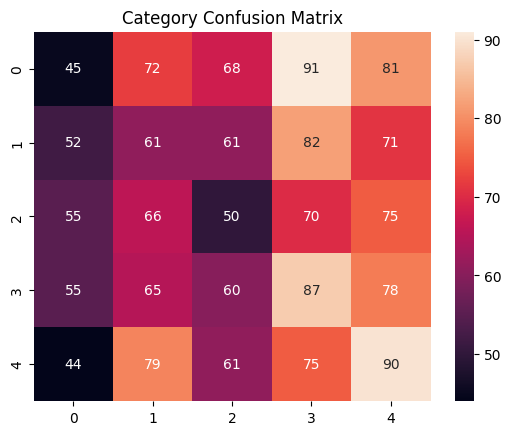


===== PRIORITY MODEL =====
Accuracy: 0.2550177095631641
              precision    recall  f1-score   support

    Critical       0.24      0.24      0.24       411
        High       0.27      0.29      0.28       409
         Low       0.22      0.21      0.22       415
      Medium       0.29      0.28      0.28       459

    accuracy                           0.26      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.26      0.25      1694



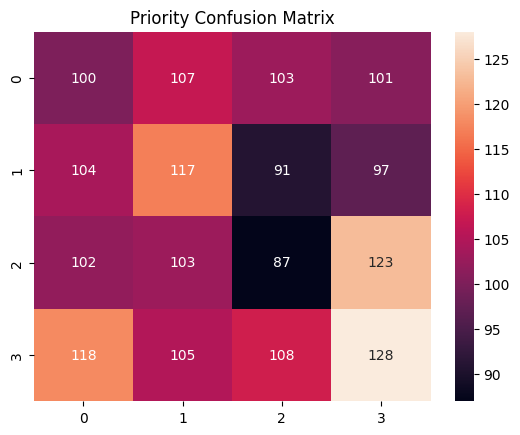


Ticket: My payment failed and money deducted
Category: Product inquiry
Priority: Critical

Ticket: System is very slow
Category: Technical issue
Priority: Critical

Ticket: Account hacked urgent help
Category: Cancellation request
Priority: Medium

Models saved successfully!


In [2]:
# ==============================
# SUPPORT TICKET ML PROJECT
# ==============================

# Install if needed
# !pip install kagglehub pandas numpy scikit-learn nltk seaborn matplotlib

import kagglehub
import os
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

# ==============================
# DOWNLOAD DATASET (KAGGLEHUB)
# ==============================
path = kagglehub.dataset_download("suraj520/customer-support-ticket-dataset")
print("Dataset path:", path)

# See files inside folder
print("Files:", os.listdir(path))

# ==============================
# LOAD DATASET (IMPORTANT FIX)
# ==============================
# ⚠️ Check the exact filename printed above
file_path = os.path.join(path, "customer_support_tickets.csv")  # adjust if needed

df = pd.read_csv(file_path)

# ==============================
# SELECT COLUMNS
# ==============================
df = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']]
df.dropna(inplace=True)

print("Dataset Shape:", df.shape)

# ==============================
# TEXT CLEANING
# ==============================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['Ticket Description'].apply(clean_text)

# ==============================
# TF-IDF
# ==============================
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])

# ==============================
# CATEGORY MODEL
# ==============================
y_category = df['Ticket Type']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

model_cat = LogisticRegression(max_iter=200)
model_cat.fit(X_train_c, y_train_c)

y_pred_c = model_cat.predict(X_test_c)

print("\n===== CATEGORY MODEL =====")
print("Accuracy:", accuracy_score(y_test_c, y_pred_c))
print(classification_report(y_test_c, y_pred_c))

cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d')
plt.title("Category Confusion Matrix")
plt.show()

# ==============================
# PRIORITY MODEL
# ==============================
y_priority = df['Ticket Priority']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

model_pri = LogisticRegression(max_iter=200)
model_pri.fit(X_train_p, y_train_p)

y_pred_p = model_pri.predict(X_test_p)

print("\n===== PRIORITY MODEL =====")
print("Accuracy:", accuracy_score(y_test_p, y_pred_p))
print(classification_report(y_test_p, y_pred_p))

cm_p = confusion_matrix(y_test_p, y_pred_p)
sns.heatmap(cm_p, annot=True, fmt='d')
plt.title("Priority Confusion Matrix")
plt.show()

# ==============================
# PREDICTION FUNCTION
# ==============================
def predict_ticket(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])

    category = model_cat.predict(vector)[0]
    priority = model_pri.predict(vector)[0]

    print("\nTicket:", text)
    print("Category:", category)
    print("Priority:", priority)

# Example
predict_ticket("My payment failed and money deducted")
predict_ticket("System is very slow")
predict_ticket("Account hacked urgent help")

# ==============================
# SAVE MODELS
# ==============================
pickle.dump(model_cat, open("category_model.pkl", "wb"))
pickle.dump(model_pri, open("priority_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("\nModels saved successfully!")